In [1]:
from data.cleaning import read_csv
from core import Config
import pandas as pd
from data.constants import constants_features

config = Config()
all_df: pd.DataFrame = read_csv(
    #filepath=config.eda_filtered_dir / "eda_filtered_historic_2026.csv",
    filepath=config.data_dir / "datasets" / "median" / "median_imputed.csv",
    #dtypes_filepath=config.eda_filtered_dir / "eda_filtered_historic_dtypes_2026.csv",
    dtypes_filepath=config.data_dir / "datasets" / "median" / "median_imputed_dtypes.csv",
    # index_list=[0]
)

Start global: univariate checks
On the full dataset (no grouping yet):

Plot and summarize each key numeric feature: histograms, boxplots, min/median/max, IQR.

Compute simple outlier heuristics per feature:

- IQR fences
- Z‑scores

This gives you a first feel for which features are “messy” and where to focus.

TODO check target values for outliers

Minimum value: 0
Maximum value: 11
Median value: 2.0
IQR value: TR.AnalyticAntiTakeoverDevices    3.0
dtype: Float64 Z-score:                   Z-score
Instrument Date          
SCATC.OL   2019 -1.114539
           2020 -1.114539
           2021 -1.114539
           2022 -1.114539
           2023 -1.114539
...                   ...
IT.N       2024  0.979646
8219.T     2021 -1.114539
           2022 -0.695702
           2023  0.141972
           2024  0.141972

[10886 rows x 1 columns]


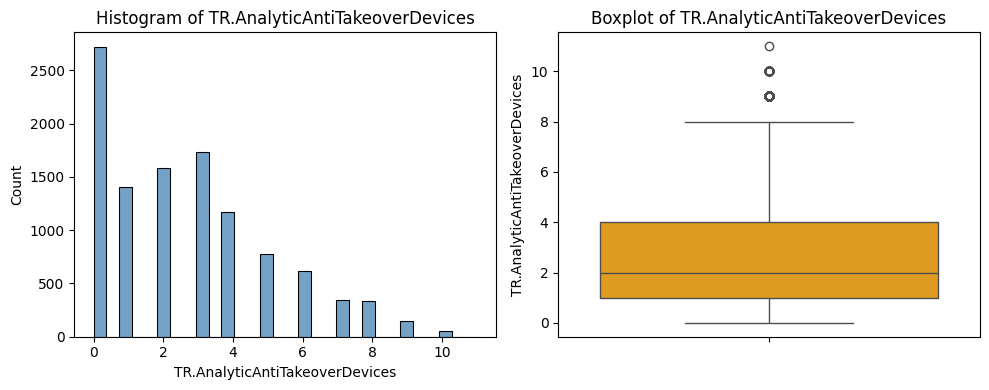

In [3]:
num_cols: list[str] = all_df.select_dtypes('number').columns.to_list()
remove_columns: set[str] = set(
    ['Date'] +
    constants_features.boolean_features +
    constants_features.float_features
)
num_cols = list(set(num_cols) - remove_columns)
num_cols.sort()
feature = num_cols[1]

import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats.mstats as mstats

def hist_and_box_sns(df, column, bins=40):
    fig, (ax_hist, ax_box) = plt.subplots(1, 2, figsize=(10, 4), sharey=False)

    sns.histplot(data=df, x=column, bins=bins, ax=ax_hist, kde=False, color="steelblue")
    ax_hist.set_title(f"Histogram of {column}")

    sns.boxplot(y=df[column], ax=ax_box, orient="v", color="orange")
    ax_box.set_title(f"Boxplot of {column}")

    fig.tight_layout()
    return fig, (ax_hist, ax_box)
dataframe = all_df[['Instrument', 'Date', feature]].dropna().set_index(['Instrument', 'Date'])

fig, axes = hist_and_box_sns(dataframe, feature, bins=30)
minimum_value = dataframe[[feature]].min().values[0]
maximum_value = dataframe[[feature]].max().values[0]
median_value = dataframe[[feature]].median().values[0]
iqr_value = dataframe[[feature]].quantile(0.75) - dataframe[[feature]].quantile(0.25)
z_values = mstats.zscore(dataframe[[feature]], axis=0)
z_score = pd.DataFrame(z_values, index=dataframe.index, columns=['Z-score'])
print(f"Minimum value: {minimum_value}\nMaximum value: {maximum_value}\nMedian value: {median_value}\nIQR value: {iqr_value} Z-score: {z_score}")
feature_df = dataframe.join(z_score).reset_index()

thr = 3
mask_outlier = feature_df['Z-score'].abs() > thr

# companies with at least one outlier for that feature
companies_with_outlier = feature_df.loc[mask_outlier, 'Instrument'].unique()

# subset: all years for those companies
df_focus = feature_df[feature_df['Instrument'].isin(companies_with_outlier)]
df_focus.sort_values(['Instrument', 'Date'], inplace=True)

In [ ]:
for col in num_cols:
    print(col)

In [ ]:
boolean_columns = all_df.select_dtypes('bool').columns.to_list()
boolean_columns.sort()
for col in boolean_columns:
    print(col)